# Confirmatory Data Analysis  Overview Example

CDA is a top-down approach in which we start with a question and use data to answer it.

1. **Experiments** are studies where the researchers explicitly assign treatments to cases (we wanted to generate this data intently)
2. **Observational Studies** are studies where no treatment has been explicitly applied (we look at past data)

**Intervention** is the term we use to describe the act of deliberately changing a variable in a system to observe the effect on other variables.

Making causal conclusions based on experiments is often reasonable, since we can randomly assign the explanatory variable(s), i.e., the treatments. However, making the same causal conclusions based on observational data can be treacherous and is not recommended.

Read more, if you are interested in: [Study design (IMS book)](https://openintro-ims.netlify.app/data-design).

## Experiment: Blind Typing

An experiment aims to confirm a hypothesis using data. Hence, we are doing CDA.

In this experiment, we want to test people who claim that they type without looking at their keyboard. Let's verify their claim. The words-per-minute typed should not significantly drop if we turn off the lights.

1. We will test our typing with the **lights on**
2. Then, we'll test again with the **lights off**

Now let's jump to action..

### Data Collection

- Experiment subjects will visit the website: https://monkeytype.com/ to undergo the typing test
- Each subject will report their own score. Which we will store down below

### Data Loading

We will use regular Python lists to store the measurements before and after the intervention.

In [19]:
# Experiment Data
scores_1 = [33, 46, 35, 28, 20, 22, 19, 25, 19, 67, 23, 19, 40, 18, 27, 44]
scores_2 = [46, 23, 36, 21, 38, 23, 22, 27, 28, 37, 37, 26, 33, 53, 9, 13]

### Verification

We expect the same participants to undergo the experiment once with the lights on and once with the lights out. 

In [20]:
# Quick Check
assert len(scores_1) == len(scores_2)

### Enter: `pandas.Series`

In Python, libraries like Pandas include data-structures and algorithms (collectively as objects) to perform calculations efficiently on lists and tables, also known as: **Series** and **DataFrames** respectively.


In [21]:
import pandas as pd

s1 = pd.Series(scores_1, name="wpm")
s1[:10]

0    33
1    46
2    35
3    28
4    20
5    22
6    19
7    25
8    19
9    67
Name: wpm, dtype: int64

Statistics:

In [22]:
print("Number of items:", len(s1))
print("Sum:", s1.sum())
print("Average:", s1.mean())
print("Median:", s1.median(),)
print("Mode:", s1.mode()[0])
print("Standard Deviation:", s1.std())

Number of items: 16
Sum: 485
Average: 30.3125
Median: 26.0
Mode: 19
Standard Deviation: 13.444794531713752


Also the largest:

In [23]:
s1.nlargest(3)

9     67
1     46
15    44
Name: wpm, dtype: int64

..and smallest values:

In [24]:
s1.nsmallest(3)

13    18
6     19
8     19
Name: wpm, dtype: int64

### Enter: `pandas.DataFrame`

- DataFrame represents tables, of multiple columns
- Let's combine the results of with and without intervention:

In [34]:
df = pd.read_csv("../../data/MonkeyType.csv")
df

,Timestamp,Name,Accuracy(Lights_On),WPM(Lights_On),Accuracy(Lights_Off),WPM(Lights_Off)
0,4/5/2026 10:21:03,fawz,0.92,26,0.71,10
1,4/5/2026 10:21:25,suh,0.83,21,0.87,28
2,4/5/2026 10:21:48,yah,0.50,2,0.55,2
3,4/5/2026 10:21:55,ran,0.90,42,0.24,80
4,4/5/2026 10:21:56,ri,0.94,26,0.94,22
5,4/5/2026 10:22:06,fer,1.00,50,0.97,49
6,4/5/2026 10:22:22,xz,0.84,27,0.90,27
7,4/5/2026 10:22:24,aaa,0.00,0,0.00,0
8,4/5/2026 10:22:56,ssa,0.21,0,0.21,0
9,4/5/2026 10:23:16,roma.7708,0.24,90,0.22,90


In [35]:
df_on = pd.DataFrame({
    'wpm': df['WPM(Lights_On)'].values,
    'acc': df['Accuracy(Lights_On)'].values,
    'intervention': [False] * len(df['WPM(Lights_On)'])
})

df_off = pd.DataFrame({
    'wpm': df['WPM(Lights_Off)'].values,
    'acc': df['Accuracy(Lights_Off)'].values,
    'intervention': [True] * len(df['WPM(Lights_Off)'])
})

In [36]:
df = pd.concat([df_on, df_off])

In [37]:
df.head()

,wpm,acc,intervention
0,26,0.92,False
1,21,0.83,False
2,2,0.50,False
3,42,0.90,False
4,26,0.94,False


In [28]:
df.tail()

,wpm,acc,intervention
9,90,0.22,True
10,47,0.00,True
11,0,0.27,True
12,12,0.45,True
13,16,0.90,True


### Overall statistics

In [38]:
df.sample(3)

,wpm,acc,intervention
12,21,0.93,False
0,10,0.71,True
9,90,0.24,False


In [39]:
df.describe()

,wpm,acc
count,28.000000,28.000000
mean,25.571429,0.593571
std,26.544761,0.364562
min,0.000000,0.000000
25%,2.000000,0.235000
50%,21.000000,0.770000
75%,31.500000,0.922500
max,90.000000,1.000000


### Statistics by group

In [41]:
df['wpm'] > 0

0      True
1      True
2      True
3      True
4      True
5      True
6      True
7     False
8     False
9      True
10     True
11    False
12     True
13     True
0      True
1      True
2      True
3      True
4      True
5      True
6      True
7     False
8     False
9      True
10     True
11    False
12     True
13     True
Name: wpm, dtype: bool

In [31]:
df.groupby(by='intervention').describe()

wpm                                                      acc  \
             count       mean        std  min  25%   50%    75%   max count   
intervention                                                                  
False         14.0  23.785714  24.498598  0.0  5.0  21.0  26.75  90.0  14.0   
True          14.0  27.357143  29.264332  0.0  4.0  19.0  42.25  90.0  14.0   

                                                                  
                  mean       std  min    25%   50%     75%   max  
intervention                                                      
False         0.670714  0.363962  0.0  0.305  0.87  0.9375  1.00  
True          0.516429  0.361591  0.0  0.225  0.50  0.8925  0.97

### Visualization: `Seaborn`

**Seaborn** is a visualization library specifically built for statistical plots. We'll use it to render the **Box-and-whiskers Plot** which visualizes the statistics described in the summary table above.

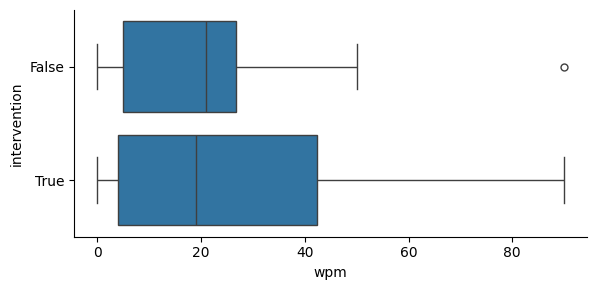

In [32]:
import seaborn as sns

sns.catplot(
    data=df,
    kind='box',
    x='wpm',
    y='intervention',
    orient='h',
    height=3, # vertical scale
    aspect=2  # Maintain proportion
)

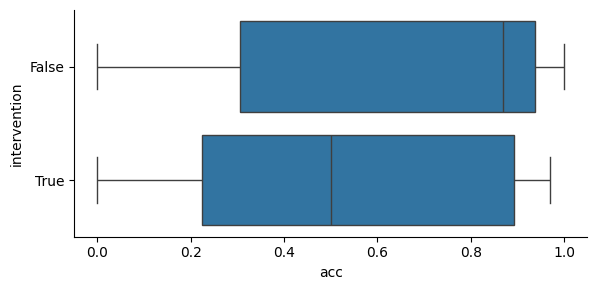

In [33]:
import seaborn as sns

sns.catplot(
    data=df,
    kind='box',
    x='acc',
    y='intervention',
    orient='h',
    height=3, # vertical scale
    aspect=2  # Maintain proportion
)

### Experiment Outcome

Question to be answered by inferential statistics: **is this difference significant?**